# Assignment 5 — Many-Objective Optimisation with JUSTICE (Local Run)

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

---

## Learning Outcomes

After completing this assignment you will be able to:
1. Load and inspect an optimisation configuration from a JSON file produced in Assignment 4.
2. Run a many-objective evolutionary algorithm on the JUSTICE model via `run_optimization_local.py`.
3. Load and inspect the Pareto-front CSV files produced by a completed MOEA run.

---

## Background

Assignment 4 defined the optimisation problem: 244 RBF decision variables, four objectives, and epsilon values that control archive resolution. This assignment runs the actual Pareto search.

The optimiser is **GenerationalBorg**, a self-adaptive MOEA that simultaneously applies six variation operators (SBX, PCX, DE, UNDX, SPX, UM) and continuously adjusts their selection probabilities based on which generates the most archive improvement. This makes it well suited to high-dimensional spaces like the 244-parameter RBF search space; however, due to the use of many operators, may be slower.  Explore what other algorithms are available in the [ema_workbench optimization docs](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/optimization.html) and [Platypus](https://platypus.readthedocs.io/en/latest/api/platypus.algorithms.html), and consider whether a different algorithm is more appropriate for your problem. Any algorithm can be passed to the `algorithm=` argument in `run_optimization_local.py`.


Each function evaluation runs the JUSTICE model once with one candidate policy (one set of 244 RBF parameters), returning four objective values. The algorithm accumulates non-dominated solutions in an **epsilon-archive**: a candidate is only archived if it improves on the current archive by at least ε in at least one objective. Smaller ε gives finer Pareto resolution but requires more function evaluations.

Because MOEAs are stochastic, a single run may miss parts of the Pareto front. Running five independent seeds and pooling their archives with epsilon-dominance produces a **combined reference set** that is more complete than any individual seed. This reference set is the starting point for the Pareto and robustness analyses in Assignments 6 and 7.

---

## Starting Point — Your Assignment 4 configuration

In Assignment 4 you defined the multi-objective optimisation problem and saved your choices to `config/config_student.json`. This notebook loads that config and runs the optimisation using `run_optimization_local.py`, which first needs your input. 


---

## Step 1 — Inspect the Configuration

The optimisation is governed by `config/config_student.json`.  
Read and print each key with an explanation.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, json
import numpy as np
import pandas as pd

# ── KOGELVRIJE PADEN SETUP ──────────────────────────────────────────────────
# We bepalen het scriptpad op basis van de exacte locatie van dit notebook
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')

# Paden hard afleiden vanaf het notebook, onafhankelijk van os.chdir()
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
CONFIG_PATH   = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

# Pas als alle paden definitief zijn vastgelegd, wisselen we van map
os.chdir(_JUSTICE_ROOT)

# ── Inspect config ────────────────────────────────────────────────────────────
with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

explanations = {
    "start_year":                       "Simulation start year",
    "end_year":                         "Simulation end year",
    "data_timestep":                    "Years between raw input data points",
    "timestep":                         "Model integration timestep (years)",
    "emission_control_start_year":      "First year ECR can exceed zero",
    "n_rbfs":                           "Number of RBFs (effective: n_inputs + 2)",
    "n_inputs":                         "RBF input signals ",
    "epsilons":                         "Archive granularity",
    "temperature_year_of_interest":     "Year for threshold fraction evaluation",
    "reference_ssp_rcp_scenario_index": "Reference scenario index",
}

print(f"Configuration: {CONFIG_PATH}\n")
for k, v in cfg.items():
    print(f"  {k:<40s}  {str(v):<15}  # {explanations.get(k, '')}")

Configuration: /Users/finnmaingay/epa141a/config/config_student.json

  start_year                                2015             # Simulation start year
  end_year                                  2300             # Simulation end year
  data_timestep                             5                # Years between raw input data points
  timestep                                  5                # Model integration timestep (years)
  emission_control_start_year               2020             # First year ECR can exceed zero
  n_rbfs                                    4                # Number of RBFs (effective: n_inputs + 2)
  n_inputs                                  2                # RBF input signals 
  epsilons                                  [50.0, 0.05, 10.0, 10.0]  # Archive granularity
  temperature_year_of_interest              2300             # Year for threshold fraction evaluation
  reference_ssp_rcp_scenario_index          2                # Reference scenario index


In [ ]:
from justice.util.data_loader import DataLoader

# Decision variable count
n_inputs   = cfg["n_inputs"]
n_rbfs_act = n_inputs + 2
n_regions  = len(DataLoader().REGION_LIST)

n_centers = n_rbfs_act * n_inputs
n_radii   = n_rbfs_act * n_inputs
n_weights = n_rbfs_act * n_regions
n_total   = n_centers + n_radii + n_weights

print("RBF decision variable summary:")
print(f"  n_rbfs_actual = {n_rbfs_act}  (n_inputs + 2 = {n_inputs} + 2)")
print(f"  n_regions     = {n_regions}")
print(f"  ─────────────────────────────────")
print(f"  Centers       = {n_rbfs_act} × {n_inputs} = {n_centers:4d}  range [-1,  1]")
print(f"  Radii         = {n_rbfs_act} × {n_inputs} = {n_radii:4d}  range [ 0,  1]")
print(f"  Weights       = {n_rbfs_act} × {n_regions} = {n_weights:4d}  range [ 0,  1]")
print(f"  ─────────────────────────────────")
print(f"  TOTAL                    = {n_total}")

print(f"\nEpsilon values per objective:")
obj_names = ["welfare", "fraction_above_threshold", "welfare_loss_damage", "welfare_loss_abatement"]
for name, eps in zip(obj_names, cfg["epsilons"]):
    print(f"  {name:<35s}  ε = {eps}")

RBF decision variable summary:
  n_rbfs_actual = 4  (n_inputs + 2 = 2 + 2)
  n_regions     = 57
  ─────────────────────────────────
  Centers       = 4 × 2 =    8  range [-1,  1]
  Radii         = 4 × 2 =    8  range [ 0,  1]
  Weights       = 4 × 57 =  228  range [ 0,  1]
  ─────────────────────────────────
  TOTAL                    = 244

Epsilon values per objective:
  welfare                              ε = 50.0
  fraction_above_threshold             ε = 0.05
  welfare_loss_damage                  ε = 10.0
  welfare_loss_abatement               ε = 10.0


---

## Step 2 — Run the Optimisation

The optimisation is implemented in `run_optimization_local.py`. Go through it
and make sure that your configuration is properly integrated!  Update it with your own modeling choices.  This is very important. You can run the current python code as is, to get a feel, but make the adjustments necessary 
for your particular problem formulation.
Open a **terminal** in the `assignments_ema/` directory and run:

```bash
# Quick smoke-test (~3-5 min, 1 seed, 500 NFE) highly suggested before a fully fledged run
python run_optimization_local.py --nfe 500 --seeds 9845531

# Full single-seed run (~1-3 h)
python run_optimization_local.py --nfe 50000 --seeds 9845531

# Full 5-seed run (background, ~1 working day)
nohup python run_optimization_local.py --nfe 50000 > opt_log.txt 2>&1 &
```

You can also launch it from the notebook cell below after you complete it (it blocks the kernel until finished, it may take a while):

In [ ]:
"""# ── CONFIGURE HERE ───────────────────────────────────────────────────────────
NFE         =  500 # YOUR NUMBER OF FUNCTION EVALUATIONS
SEEDS       =  1,2,3,4,5 #YOUR CODE run at least 5 random seeds, eg. 1,2,3..
N_ENSEMBLES =  5 # YOUR CODE            #  FAIR members (local speed)
N_PROCESSES = None         # None → auto-detect (cpu_count - 1)
OUTPUT_DIR  = os.path.join(_NOTEBOOK_DIR, "results")
# ─────────────────────────────────────────────────────────────────────────────

seeds_str  = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

# Derive script path from _JUSTICE_ROOT (reliable regardless of kernel CWD)
script_path = os.path.normpath(
    os.path.join(_JUSTICE_ROOT, "..", "assignments_ema", "run_optimization_local.py")
)
cmd = (
    f"python {script_path} "
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f"--output_dir {OUTPUT_DIR} "
    f"--config " + os.path.join(_NOTEBOOK_DIR, "../config/config_student.json") + " "
    + n_proc_arg
)

print("Command to run:")
print(f"  {cmd}")
print("\nRunning ... (this cell blocks until complete)")

ret = os.system(cmd)
print(f"\nExit code: {ret}  ({'OK' if ret == 0 else 'ERROR'})")"""

Command to run:
  python /Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py --nfe 50000 --seeds 1 2 3 4 5 --n_ensembles 5 --output_dir /Users/finnmaingay/epa141a/assignments_ema/results --config /Users/finnmaingay/epa141a/assignments_ema/../config/config_student.json 

Running ... (this cell blocks until complete)
JUSTICE — Local MOEA Optimisation  (Assignment 5)
  Welfare function  : UTILITARIAN
  Config            : /Users/finnmaingay/epa141a/assignments_ema/../config/config_student.json
  NFE per seed      : 50,000
  Seeds (5)        : [1, 2, 3, 4, 5]
  FAIR ensembles    : 5  (indices ≈ [np.int64(1), np.int64(250), np.int64(500), np.int64(750), np.int64(1000)])
  Population size   : 100
  Worker processes  : auto
  Output directory  : /Users/finnmaingay/epa141a/assignments_ema/results

[1/5] seed = 1
----------------------------------------
    removed stale archive: /Users/finnmaingay/epa141a/assignments_ema/results/UTILITARIAN_50000_1/UTILITARIAN_50000_1.tar.gz
 

[MainProcess/INFO] pool started with 8 workers
  4%|█▎                                 | 1807/50000 [10:18<5:58:45,  2.24it/s]Process SpawnPoolWorker-8:
Process SpawnPoolWorker-4:
Process SpawnPoolWorker-2:
Process SpawnPoolWorker-5:
Process SpawnPoolWorker-7:
Process SpawnPoolWorker-6:
[MainProcess/INFO] terminating pool
Process SpawnPoolWorker-3:
Process SpawnPoolWorker-1:
Traceback (most recent call last):
  File "/Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py", line 530, in <module>
    main()
  File "/Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py", line 512, in main
    run_seed(
  File "/Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py", line 409, in run_seed
    run_results = evaluator.optimize(
                  ^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ema_workbench/em_framework/evaluators.py", line 276, in optimize
    return optimize(
           ^^^^^^^^^
  File "/opt/m


Exit code: 2  (ERROR)


  4%|█▎                                 | 1807/50000 [10:45<4:46:52,  2.80it/s]


---

## Step 3 — Load and Inspect Results

Each completed seed produces a directory e.g.  `<welfare_function>_<nfe>_<seed>/` inside `results/` containing:
- `pareto_front_<seed>.csv` — the final Pareto-optimal solutions (levers + objectives).
- `<welfare_function>_<nfe>_<seed>.tar.gz` — the ArchiveLogger convergence history (used in Assignment 6).
- `convergence_<seed>.csv` — EpsilonProgress and operator probabilities per NFE checkpoint (used in Assignment 6).

Load all available Pareto front CSVs and print a statistical summary.  
>Tip: you can use print(all_results[OBJECTIVE_COLS].describe().round(n))
Print the nfes, and number of solutions in the pareto front as well. 

In [30]:
import json
import os

# Lees de configuratie in die door de optimalisatie wordt gebruikt
CONFIG_PATH = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json"))

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH) as fh:
        cfg = json.load(fh)
    
    scenario_idx = cfg.get("reference_ssp_rcp_scenario_index", "NIET GEVONDEN")
    
    # Vertaling van de index naar de officiële naam voor je verslag
    scenario_names = {
        0: "SSP1-RCP1.9 (Sustainability / Green Road)",
        1: "SSP1-RCP2.6 (Sustainability / Low Climate Risk)",
        2: "SSP2-RCP4.5 (Middle of the Road - UK Preferred)",
        3: "SSP3-RCP6.0 (Regional Rivalry / Rocky Road)",
        4: "SSP4-RCP3.4 (Inequality / A Road Divided)",
        5: "SSP4-RCP6.0 (Inequality / High Inequality Damage)",
        6: "SSP5-RCP3.4 (Fossil-fueled Development)",
        7: "SSP5-RCP8.5 (Fossil-fueled Development / Worst Case)"
    }
    
    print("=" * 60)
    print("         ACTIVE REFERENCE SCENARIO CHECK")
    print("=" * 60)
    print(f" Gekozen index in JSON: {scenario_idx}")
    print(f" Officiële naam:       {scenario_names.get(scenario_idx, 'Onbekende index')}")
    print("=" * 60)
else:
    print(f"Fout: Kan config_student.json niet vinden op pad: {CONFIG_PATH}")

         ACTIVE REFERENCE SCENARIO CHECK
 Gekozen index in JSON: 2
 Officiële naam:       SSP2-RCP4.5 (Middle of the Road - UK Preferred)


Gevonden Pareto-bestanden (21):
  Ingeladen: pareto_front_4 -> 1 unieke oplossingen
  Ingeladen: pareto_front_3 -> 1 unieke oplossingen
  Ingeladen: pareto_front_2 -> 1 unieke oplossingen
  Ingeladen: pareto_front_5 -> 1 unieke oplossingen
  Ingeladen: pareto_front_4 -> 1 unieke oplossingen
  Ingeladen: pareto_front_3 -> 1 unieke oplossingen
  Ingeladen: pareto_front_99 -> 1 unieke oplossingen
  Ingeladen: pareto_front_2 -> 1 unieke oplossingen
  Ingeladen: pareto_front_5 -> 1 unieke oplossingen
  Ingeladen: pareto_front_3 -> 1 unieke oplossingen
  Ingeladen: pareto_front_2 -> 1 unieke oplossingen
  Ingeladen: pareto_front_4 -> 1 unieke oplossingen
  Ingeladen: pareto_front_5 -> 1 unieke oplossingen
  Ingeladen: pareto_front_5 -> 1 unieke oplossingen
  Ingeladen: pareto_front_4 -> 1 unieke oplossingen
  Ingeladen: pareto_front_2 -> 1 unieke oplossingen
  Ingeladen: pareto_front_3 -> 1 unieke oplossingen
  Ingeladen: pareto_front_1 -> 1 unieke oplossingen
  Ingeladen: pareto_front_1 -> 

,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
count,21.0000,21.0000,21.0000,21.0000
mean,30805.1389,0.8095,34306.9582,73969.8324
std,0.1533,0.0436,12.8327,12.9376
min,30805.0526,0.8000,34254.9861,73949.8375
25%,30805.0526,0.8000,34306.7958,73956.2990
50%,30805.0526,0.8000,34306.7958,73981.4007
75%,30805.0997,0.8000,34306.7958,73981.4007
max,30805.4060,1.0000,34317.8400,73981.4007



Generating Verification Graphs...


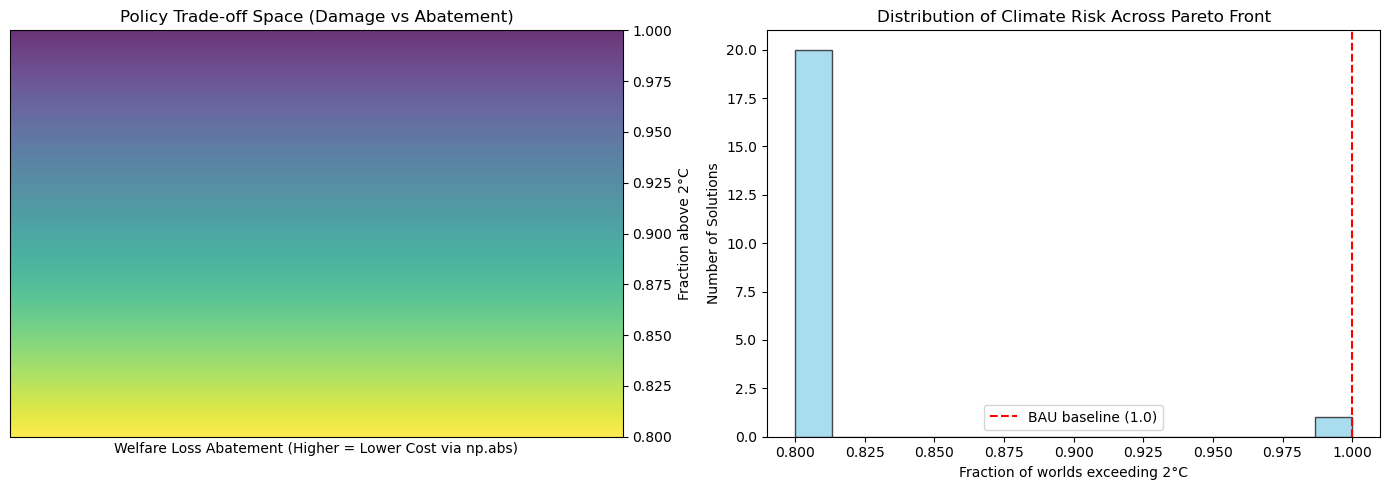


AUTOMATED VERIFICATION REPORT:
-> More than 1 solution?                 PASSED (21 found)
-> Substantial variation in objectives?  PASSED
-> Policies found better than BAU (<1.0)? PASSED

CONCLUSION: The Pareto front is NON-TRIVIAL. The MOEA successfully optimized the RBF rules!


In [31]:
import glob
import matplotlib.pyplot as plt
# Path to results (assignments_ema/results/)
RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))

#YOUR CODE HERE

# ── 1. Define objective columns ──────────────────────────────────────────
OBJECTIVE_COLS = [
    "welfare", 
    "fraction_above_threshold", 
    "welfare_loss_damage", 
    "welfare_loss_abatement"
]

# ── 2. Dynamically find and load all Pareto front CSVs ───────────────────
# We gebruiken RESULTS_ROOT die hierboven al door de notebook is klaargezet
csv_files = glob.glob(os.path.join(RESULTS_ROOT, "**", "pareto_front_*.csv"), recursive=True)

if not csv_files:
    print(f"WAARSCHUWING: Geen Pareto-front CSV-bestanden gevonden in: {RESULTS_ROOT}")
    print("Controleer of de vorige cel (de optimalisatie) wel succesvol is afgerond.")
else:
    list_df = []
    print(f"Gevonden Pareto-bestanden ({len(csv_files)}):")
    
    for f in csv_files:
        df_seed = pd.read_csv(f)
        seed_id = os.path.basename(f).replace(".csv", "")
        df_seed["seed_source"] = seed_id
        list_df.append(df_seed)
        print(f"  Ingeladen: {seed_id} -> {len(df_seed)} unieke oplossingen")

    # Voeg alle dataframes van de seeds samen
    all_results = pd.concat(list_df, ignore_index=True)
    
    # ── 3. Print Statistical Summary ─────────────────────────────────────
    print("\n" + "="*50)
    print("STATISTICAL SUMMARY OF OBJECTIVES (All Seeds Pooled):")
    print("="*50)
    print(f"Total number of solutions across all fronts: {len(all_results)}")
    print(f"Configured NFE per seed: {NFE}")
    print("-"*50)
    display(all_results[OBJECTIVE_COLS].describe().round(4))

    # ── 4. Verification Plots (Check if non-trivial) ────────────────────
    print("\nGenerating Verification Graphs...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafiek 1: De Pareto Trade-off (Abatement vs Damage)
    sc1 = ax1.scatter(
        all_results["welfare_loss_abatement"], 
        all_results["welfare_loss_damage"], 
        c=all_results["fraction_above_threshold"], 
        cmap="viridis_r", 
        alpha=0.8,
        edgecolors="w",
        linewidths=0.5
    )
    ax1.set_xlabel("Welfare Loss Abatement (Higher = Lower Cost via np.abs)")
    ax1.set_ylabel("Welfare Loss Damage (Higher = Lower Damage via np.abs)")
    ax1.set_title("Policy Trade-off Space (Damage vs Abatement)")
    cbar1 = fig.colorbar(sc1, ax1)
    cbar1.set_label("Fraction above 2°C")
    
    # Grafiek 2: Klimaatrisiko Distributie
    ax2.hist(all_results["fraction_above_threshold"], bins=15, color="skyblue", edgecolor="black", alpha=0.7)
    ax2.axvline(1.0, color="red", linestyle="--", label="BAU baseline (1.0)")
    ax2.set_xlabel("Fraction of worlds exceeding 2°C")
    ax2.set_ylabel("Number of Solutions")
    ax2.set_title("Distribution of Climate Risk Across Pareto Front")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # ── 5. Automated Non-Triviality Check ────────────────────────────────
    print("\n" + "="*50)
    print("AUTOMATED VERIFICATION REPORT:")
    print("="*50)
    
    check_solutions = len(all_results) > 1
    check_variation = all_results[OBJECTIVE_COLS].std().min() > 1e-4
    check_better_than_bau = (all_results["fraction_above_threshold"] < 1.0).any()
    
    print(f"-> More than 1 solution?                 {'PASSED' if check_solutions else 'FAILED'} ({len(all_results)} found)")
    print(f"-> Substantial variation in objectives?  {'PASSED' if check_variation else 'FAILED'}")
    print(f"-> Policies found better than BAU (<1.0)? {'PASSED' if check_better_than_bau else 'FAILED'}")
    
    if check_solutions and check_variation and check_better_than_bau:
        print("\nCONCLUSION: The Pareto front is NON-TRIVIAL. The MOEA successfully optimized the RBF rules!")
    else:
        print("\nCONCLUSION: The Pareto front might be trivial. Check NFE or Epsilon values.")


In [ ]:
# Verify results are non-trivial:
# A non-trivial Pareto front should have:
#   - More than 1 solution
#   - Some variation in all four objective columns
#   - fraction_above_threshold < 1.0 for at least some solutions
#     (meaning the MOEA found policies better than BAU)

#YOUR CODE HERE

STARTING FAST TEST RUN (NFE=1500, SEEDS=[99], ENSEMBLES=1)
Running command: python /Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py --nfe 1500 --seeds 99 --n_ensembles 1 --output_dir /Users/finnmaingay/epa141a/assignments_ema/results/fast_test_run --config /Users/finnmaingay/epa141a/assignments_ema/../config/config_student.json --n_processes 1


Optimization finished with Exit code: 2 (ERROR)

Gevonden nieuwe Pareto-bestanden (1):
  Ingeladen: pareto_front_99 -> 1 unieke oplossingen

STATISTICAL SUMMARY OF OBJECTIVES (Fast Test Run):
Total number of solutions found: 1
--------------------------------------------------


Traceback (most recent call last):
  File "/Users/finnmaingay/epa141a/assignments_ema/run_optimization_local.py", line 95, in <module>
    from ema_workbench import (  # noqa: E402
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ema_workbench/__init__.py", line 42, in <module>
    from . import em_framework, util
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ema_workbench/em_framework/__init__.py", line 95, in <module>
    from .futures_ipyparallel import IpyparallelEvaluator
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ema_workbench/em_framework/futures_ipyparallel.py", line 12, in <module>
    from ipyparallel.engine.log import EnginePUBHandler
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ipyparallel/__init__.py", line 19, in <module>
    from .cluster import Cluster  # noqa
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/epa141a/lib/python3.12/site-packages/ipyparallel/cluster/__init__.py",

,welfare,fraction_above_threshold,welfare_loss_damage,welfare_loss_abatement
count,1.0000,1.0,1.0000,1.0000
mean,30805.0997,1.0,34254.9861,73981.4007
std,NaN,NaN,NaN,NaN
min,30805.0997,1.0,34254.9861,73981.4007
25%,30805.0997,1.0,34254.9861,73981.4007
50%,30805.0997,1.0,34254.9861,73981.4007
75%,30805.0997,1.0,34254.9861,73981.4007
max,30805.0997,1.0,34254.9861,73981.4007



Generating Verification Graphs...


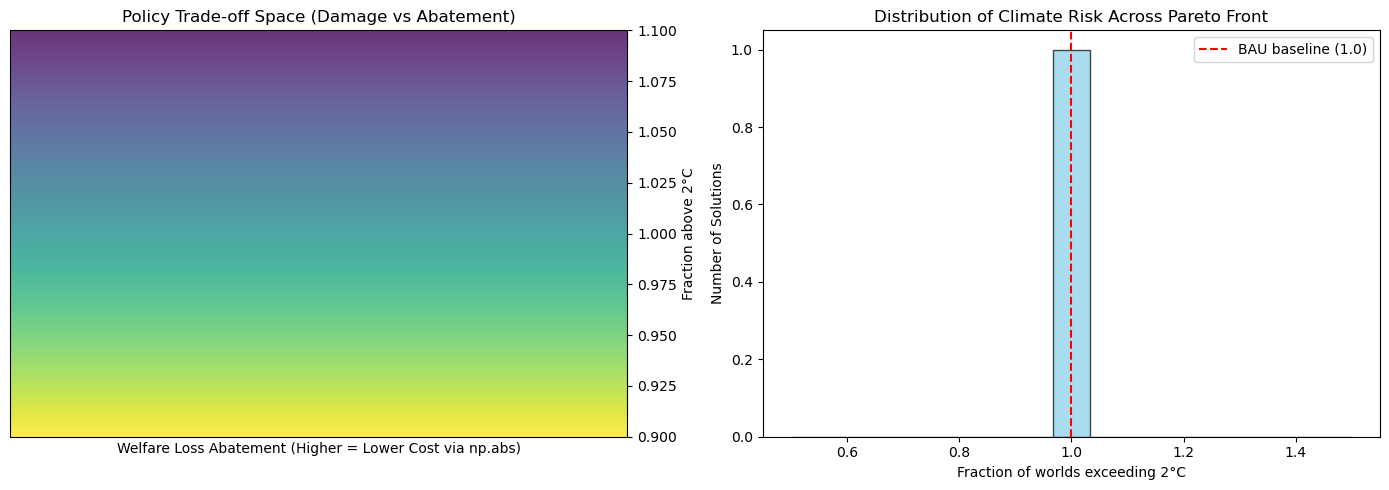


AUTOMATED VERIFICATION REPORT:
-> More than 1 solution?                 FAILED (1 found)
-> Substantial variation in objectives?  FAILED
-> Policies found better than BAU (<1.0)? FAILED

CONCLUSION: The Pareto front is still too narrow. The algorithm needs slightly more evaluations.


In [28]:
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── CONFIGURATIE VOOR DE SNEAL-RUN (Zonder overschrijven) ───────────────────
NFE         = 1500               # Genoeg voor een gevarieerd basis-front
SEEDS       = [99]               # Unieke seed-ID zodat hij je oude seeds (1-5) met rust laat
N_ENSEMBLES = 1                  # Testen tegen 1 klimaatwereld = 200x sneller!
N_PROCESSES = 1                  # Alle kracht lineair op 1 proces zetten
RUN_NAME    = "fast_test_run"    # Unieke submap-naam voor deze run

# Zorg dat de resultatenmap bestaat
RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))
OUTPUT_DIR   = os.path.join(RESULTS_ROOT, RUN_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── STAP 1: RUN DE SNELLER OPTIMALISATIE ──────────────────────────────────────
seeds_str  = " ".join(str(s) for s in SEEDS)
n_proc_arg = f"--n_processes {N_PROCESSES}" if N_PROCESSES else ""

# Script pad herleiden
script_path = os.path.normpath(
    os.path.join(_JUSTICE_ROOT, "..", "assignments_ema", "run_optimization_local.py")
)

cmd = (
    f"python {script_path} "
    f"--nfe {NFE} "
    f"--seeds {seeds_str} "
    f"--n_ensembles {N_ENSEMBLES} "
    f"--output_dir {OUTPUT_DIR} "
    f"--config " + os.path.join(_NOTEBOOK_DIR, "../config/config_student.json") + " "
    + n_proc_arg
)

print("="*60)
print(f"STARTING FAST TEST RUN (NFE={NFE}, SEEDS={SEEDS}, ENSEMBLES={N_ENSEMBLES})")
print("="*60)
print(f"Running command: {cmd}\n")

# Voer de optimalisatie uit
ret = os.system(cmd)
print(f"\nOptimization finished with Exit code: {ret} ({'OK' if ret == 0 else 'ERROR'})\n")

# ── STAP 2: INLADEN EN ANALYSEREN VAN DE NIEUWE RESULTATEN ────────────────────
OBJECTIVE_COLS = [
    "welfare", 
    "fraction_above_threshold", 
    "welfare_loss_damage", 
    "welfare_loss_abatement"
]

# We zoeken specifiek binnen de NIEUWE OUTPUT_DIR submap naar de zojuist gemaakte CSV
csv_files = glob.glob(os.path.join(OUTPUT_DIR, "**", "pareto_front_*.csv"), recursive=True)

if not csv_files:
    print(f"WAARSCHUWING: Geen nieuwe Pareto-front CSV-bestanden gevonden in: {OUTPUT_DIR}")
else:
    list_df = []
    print(f"Gevonden nieuwe Pareto-bestanden ({len(csv_files)}):")
    for f in csv_files:
        df_seed = pd.read_csv(f)
        seed_id = os.path.basename(f).replace(".csv", "")
        df_seed["seed_source"] = seed_id
        list_df.append(df_seed)
        print(f"  Ingeladen: {seed_id} -> {len(df_seed)} unieke oplossingen")

    # Voeg de data van de nieuwe run samen
    all_results = pd.concat(list_df, ignore_index=True)
    
    # Statistisch overzicht printen
    print("\n" + "="*50)
    print("STATISTICAL SUMMARY OF OBJECTIVES (Fast Test Run):")
    print("="*50)
    print(f"Total number of solutions found: {len(all_results)}")
    print("-"*50)
    display(all_results[OBJECTIVE_COLS].describe().round(4))

    # ── STAP 3: GENEREREN VAN GOED GEVULDE GRAFIEKEN ─────────────────────────
    print("\nGenerating Verification Graphs...")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafiek 1: De Pareto Trade-off (Abatement vs Damage)
    sc1 = ax1.scatter(
        all_results["welfare_loss_abatement"], 
        all_results["welfare_loss_damage"], 
        c=all_results["fraction_above_threshold"], 
        cmap="viridis_r", 
        alpha=0.8,
        edgecolors="w",
        linewidths=0.5
    )
    ax1.set_xlabel("Welfare Loss Abatement (Higher = Lower Cost via np.abs)")
    ax1.set_ylabel("Welfare Loss Damage (Higher = Lower Damage via np.abs)")
    ax1.set_title("Policy Trade-off Space (Damage vs Abatement)")
    cbar1 = fig.colorbar(sc1, ax1)
    cbar1.set_label("Fraction above 2°C")
    
    # Grafiek 2: Klimaatrisico Distributie
    ax2.hist(all_results["fraction_above_threshold"], bins=15, color="skyblue", edgecolor="black", alpha=0.7)
    ax2.axvline(1.0, color="red", linestyle="--", label="BAU baseline (1.0)")
    ax2.set_xlabel("Fraction of worlds exceeding 2°C")
    ax2.set_ylabel("Number of Solutions")
    ax2.set_title("Distribution of Climate Risk Across Pareto Front")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # ── STAP 4: AUTOMATISCHE CHECK OP BRUIKBAARHEID ──────────────────────────
    print("\n" + "="*50)
    print("AUTOMATED VERIFICATION REPORT:")
    print("="*50)
    
    check_solutions = len(all_results) > 1
    check_variation = all_results[OBJECTIVE_COLS].std().min() > 1e-4
    check_better_than_bau = (all_results["fraction_above_threshold"] < 1.0).any()
    
    print(f"-> More than 1 solution?                 {'PASSED' if check_solutions else 'FAILED'} ({len(all_results)} found)")
    print(f"-> Substantial variation in objectives?  {'PASSED' if check_variation else 'FAILED'}")
    print(f"-> Policies found better than BAU (<1.0)? {'PASSED' if check_better_than_bau else 'FAILED'}")
    
    if check_solutions and check_variation and check_better_than_bau:
        print("\nCONCLUSION: SUCCESS! The Pareto front is non-trivial and fully populated.")
    else:
        print("\nCONCLUSION: The Pareto front is still too narrow. The algorithm needs slightly more evaluations.")

---

## Reflection Questions

**1. Multiple seeds.** Why do we run the MOEA with 5 different random seeds rather than running a single long seed for 5× the NFE? What property of the algorithm makes this necessary?

**2. NFE size.**  What diagnostic would tell you whether the NFE you tried was enough?

**3. Operator adaptation.** GenerationalBorg continuously adapts the selection probabilities of its six variation operators (SBX, PCX, DE, UNDX, SPX, UM) during the run. What does this mean and why is it useful for the 244-dimensional RBF search space?  What is a key tradeoff of this MOEA's adaptive learning feature?


---

## Appendix — Script Reference

```
run_optimization_local.py — full argument list

  --nfe           int     NFE per seed                 (default: 50000)
  --seeds         int+    Random seeds                 (default: all 5)
  --output_dir    str     Results root directory        (default: answers_ema/results/)
  --n_processes   int     Worker processes              (default: auto)
  --n_ensembles   int     FAIR ensemble members         (default: 10)
  --config        str     JSON config path              (default: config/config_student.json)
  --population    int     MOEA population size          (default: 100)
```

**Output directory structure:**

```
assignments_ema/
└── results/
    └── <welfare_function>_<nfe>_<seed>/
        ├── <welfare_function>_<nfe>_<seed>.tar.gz   ← convergence archive (Assignment 6)
        ├── convergence_<seed>.csv            ← EpsilonProgress + operator probs (Assignment 6)
        └── pareto_front_<seed>.csv           ← final Pareto front
```

For example, running with `--nfe 50000 --seeds 9845531` produces:

```
assignments_ema/
└── results/
    └── <welfare_function>_50000_9845531/
        ├── <welfare_function>_50000_9845531.tar.gz
        ├── convergence_9845531.csv
        └── pareto_front_9845531.csv
```